# 05 — Leduc Poker (2 jugadores): CFR e ISMCTS

**Obligatorio 2 — Sistemas Multiagente**

Leduc Hold'em es un benchmark clásico de información imperfecta, **más grande que
Kuhn**: baraja de 6 cartas (J, Q, K ×2), una carta privada por jugador, **dos
rondas** de apuestas y una **carta comunitaria** revelada entre rondas. El árbol de
juego (y el número de *information sets*) es mucho mayor, ideal para estudiar la
**escalabilidad** de CFR.

Usamos la implementación de la **cátedra** (`games/leduc.py`, clase `Leduc`), que
envuelve `pettingzoo.classic.leduc_holdem_v4` (rlcard). Los jugadores se llaman
`player_0` y `player_1`, y las recompensas están en **fichas** (no en ±1).

> A la versión de la cátedra se le añadieron únicamente: un `clone()` correcto (el
> `deepcopy` del entorno de PettingZoo reinicia el estado interno del juego) y un
> `random_change` (determinización) para soportar ISMCTS. Requiere instalar
> `pettingzoo[classic]` (trae rlcard y pygame).

In [1]:
import sys, os
try:
    ROOT = os.path.dirname(__vsc_ipynb_file__)   # VS Code
except NameError:
    ROOT = os.getcwd()                            # Jupyter / fallback
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Raiz del proyecto:", ROOT)

Raiz del proyecto: C:\Users\joaco\Documents\ort\semestre_3\obligatorio2-sma\obligatorio_2_joaco


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

from games.leduc import Leduc
from agents.cfr import CounterFactualRegret
from agents.ismcts import ISMCTS
from agents.agent_random import RandomAgent
from utils import run_games, matchup_both_sides, cfr_policy_agent

np.random.seed(42)
print("Agentes:", Leduc().agents, "| acciones:", Leduc().num_actions(Leduc().agents[0]))

Agentes: ['player_0', 'player_1'] | acciones: 4


## 1. CFR: escalabilidad con las iteraciones

Entrenamos CFR con distinto número de iteraciones y medimos: *information sets*
descubiertos, tiempo de entrenamiento y recompensa media (en fichas) contra Random.

In [3]:
rows = []
for niter in [50, 100, 200]:
    g = Leduc()
    cfr = CounterFactualRegret(g, g.agents[0])
    t0 = time.time(); cfr.train(niter=niter); train_time = time.time() - t0
    res = matchup_both_sides(lambda: Leduc(), make_a=cfr_policy_agent(cfr),
                             make_b=lambda gg, aa: RandomAgent(gg, aa), n_games=120)
    rows.append({'iteraciones': niter, 'info_sets': len(cfr.node_dict),
                 'train_time_s': round(train_time, 1), 'reward_vs_random': res['mean_reward_A']})
    print(f"  niter={niter}: info_sets={len(cfr.node_dict)}, train={train_time:.1f}s, reward={res['mean_reward_A']:.3f}")
df_cfr = pd.DataFrame(rows)
df_cfr

  niter=50: info_sets=69, train=17.2s, reward=0.100


  niter=100: info_sets=72, train=37.1s, reward=0.317


  niter=200: info_sets=72, train=75.2s, reward=0.185


,iteraciones,info_sets,train_time_s,reward_vs_random
0,50,69,17.2,0.100000
1,100,72,37.1,0.316667
2,200,72,75.2,0.185417


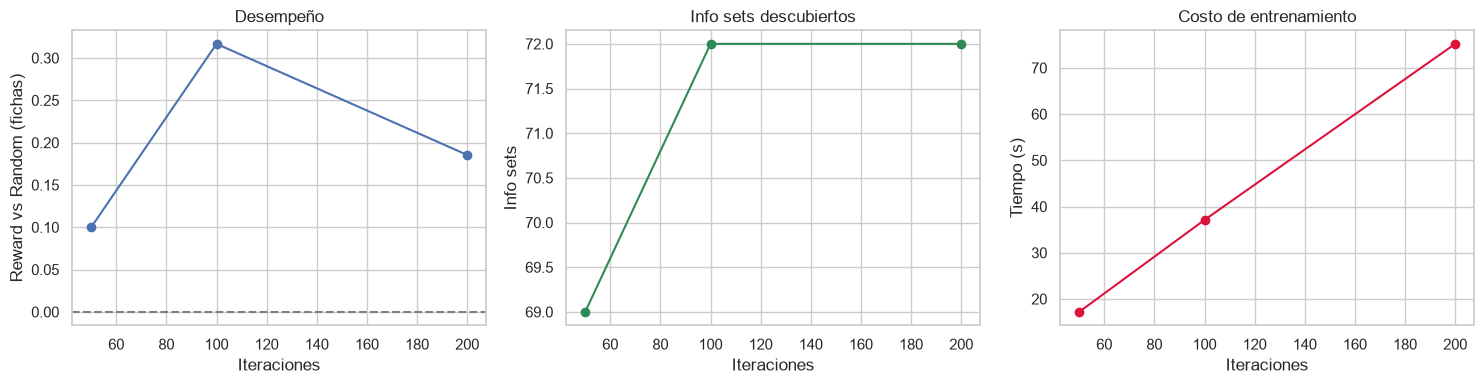

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df_cfr.iteraciones, df_cfr.reward_vs_random, 'o-'); ax[0].axhline(0, color='gray', ls='--')
ax[0].set(xlabel='Iteraciones', ylabel='Reward vs Random (fichas)', title='Desempeño')
ax[1].plot(df_cfr.iteraciones, df_cfr.info_sets, 'o-', color='seagreen')
ax[1].set(xlabel='Iteraciones', ylabel='Info sets', title='Info sets descubiertos')
ax[2].plot(df_cfr.iteraciones, df_cfr.train_time_s, 'o-', color='crimson')
ax[2].set(xlabel='Iteraciones', ylabel='Tiempo (s)', title='Costo de entrenamiento')
plt.tight_layout(); plt.show()

## 2. CFR vs ISMCTS vs Random

In [5]:
g = Leduc()
cfr = CounterFactualRegret(g, g.agents[0]); cfr.train(niter=200)

rows = []
res = matchup_both_sides(lambda: Leduc(), make_a=cfr_policy_agent(cfr),
                         make_b=lambda gg, aa: RandomAgent(gg, aa), n_games=100)
rows.append({'enfrentamiento': 'CFR vs Random', 'reward_A': res['mean_reward_A']})
for s in [50, 100]:
    res = matchup_both_sides(lambda: Leduc(),
        make_a=lambda gg, aa, s=s: ISMCTS(gg, aa, simulations=s),
        make_b=lambda gg, aa: RandomAgent(gg, aa), n_games=25)
    rows.append({'enfrentamiento': f'ISMCTS({s}) vs Random', 'reward_A': res['mean_reward_A']})
res = matchup_both_sides(lambda: Leduc(), make_a=cfr_policy_agent(cfr),
                         make_b=lambda gg, aa: ISMCTS(gg, aa, simulations=100), n_games=25)
rows.append({'enfrentamiento': 'CFR vs ISMCTS(100)', 'reward_A': res['mean_reward_A']})
df_h = pd.DataFrame(rows)
df_h.round(3)

,enfrentamiento,reward_A
0,CFR vs Random,0.32
1,ISMCTS(50) vs Random,0.53
2,ISMCTS(100) vs Random,0.97
3,CFR vs ISMCTS(100),-0.73


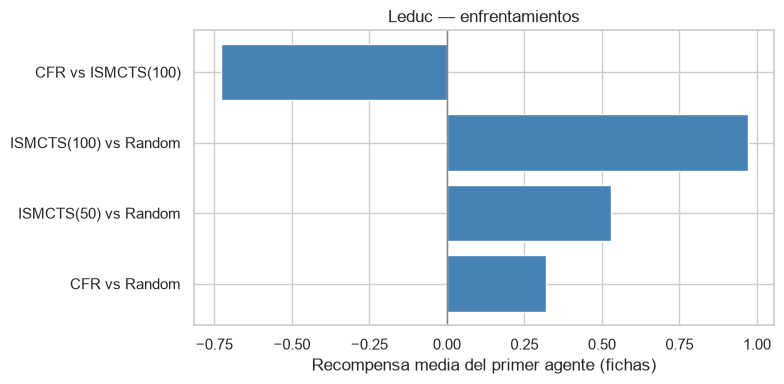

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_h['enfrentamiento'], df_h['reward_A'], color='steelblue')
ax.axvline(0, color='gray', lw=1)
ax.set(xlabel='Recompensa media del primer agente (fichas)', title='Leduc — enfrentamientos')
plt.tight_layout(); plt.show()

## Conclusiones — Leduc Poker

- El número de *information sets* y el tiempo de entrenamiento de CFR **crecen
  fuertemente** respecto a Kuhn: Leduc es un orden de magnitud más complejo.
- CFR aprende una estrategia que **vence a Random** de forma clara (reward positivo
  en fichas) ya con pocas iteraciones.
- **Sobre la no-monotonicidad del barrido de CFR** (`niter=100 → 0.317` pero
  `niter=200 → 0.185`): no es una degradación del algoritmo, sino **varianza de
  evaluación**. La evaluación usa pocas partidas (`n=120`) y las recompensas están
  en *fichas* (rango amplio, alta varianza), por lo que el error estándar del reward
  es grande y domina sobre la mejora real entre 100 y 200 iteraciones. Con CFR la
  *explotabilidad* baja monótonamente con las iteraciones, pero el *reward medido
  contra Random* con pocos juegos es ruidoso. Para una curva limpia harían falta
  muchas más partidas de evaluación (y/o más iteraciones), a un costo de cómputo
  considerable dado lo caro que es clonar el entorno de Leduc.
- ISMCTS es competitivo y no requiere entrenamiento previo; su desempeño mejora con
  el presupuesto de simulaciones (50 → 100) pero es más costoso por jugada.
  (Recompensas expresadas en fichas del juego.)